# Bab 5 — Classification
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. Naive Bayes
2. Discriminant analysis (LDA)
3. Logistic regression
4. Generalized linear models (GLM) dan GAM untuk klasifikasi
5. Evaluasi model klasifikasi (confusion matrix, precision, recall, specificity, ROC, AUC, lift)
6. Strategi untuk data tidak seimbang (undersampling, oversampling/up-weighting, SMOTE, cost-based)
7. Menjelajahi prediksi: membandingkan batas keputusan beberapa model


In [1]:
!pip install statsmodels imbalanced-learn

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, roc_auc_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## Gambaran Besar

Banyak masalah data science berbentuk **klasifikasi**: memprediksi kategori, bukan angka.
- Apakah email ini spam atau bukan?
- Apakah pelanggan akan berhenti berlangganan (*churn*)?
- Apakah peminjam akan gagal bayar (*default*)?
- Apakah pengunjung akan mengklik iklan?

Kebanyakan algoritma klasifikasi tidak langsung menghasilkan label, tetapi **probabilitas** termasuk ke tiap kelas. Lalu kita memilih **cutoff** (ambang): jika probabilitas di atas cutoff, prediksinya "1".

Langkah umumnya:
1. Tentukan cutoff probabilitas untuk kelas yang diminati (kelas "1").
2. Estimasi probabilitas setiap record termasuk kelas tersebut.
3. Jika probabilitas ≥ cutoff, tetapkan record ke kelas tersebut.

Cutoff yang lebih tinggi menghasilkan lebih sedikit prediksi "1"; cutoff yang lebih rendah menghasilkan lebih banyak.

**Lebih dari dua kelas?** Masalah multikelas sering bisa dipecah menjadi beberapa masalah biner. Contoh: churn dibagi menjadi *tidak churn*, *churn ke kompetitor*, dan *churn karena berhenti total*. Kita bisa memodelkan "churn vs tidak", lalu di antara yang churn, "jenis churn apa". Ini juga berguna ketika satu kelas jauh lebih umum daripada yang lain.

Contoh data utama di bab ini: **pinjaman LendingClub**. Outcome-nya `paid off` (lunas) atau `default` (gagal bayar).

## 1. Naive Bayes

**Istilah kunci:**
- **Conditional probability** — probabilitas suatu kejadian jika kejadian lain sudah diketahui, ditulis $P(X_i \mid Y_i)$.
- **Posterior probability** — probabilitas outcome **setelah** informasi prediktor diperhitungkan (berbeda dari *prior probability*, yang tidak memperhitungkan prediktor).

### Klasifikasi Bayes yang Eksak (dan kenapa tidak praktis)
Ide dasarnya: untuk record baru, cari semua record lain dengan **nilai prediktor yang persis sama**, lalu lihat kelas mana yang paling banyak. Masalahnya: begitu jumlah prediktor bertambah, hampir tidak ada record yang **persis** sama. Dengan hanya 5 prediktor yang masing-masing punya 4 kategori, sudah ada $4^5 = 1.024$ kombinasi, dan kebanyakan tidak punya data.

### Solusi "Naive"
Naive Bayes tidak mencari kecocokan persis. Ia memakai seluruh data dan **mengasumsikan prediktor saling independen** (asumsi yang "naif"):

1. Untuk biner *Y* = 1, estimasi probabilitas tiap prediktor secara terpisah: $P(X_j \mid Y = 1)$. Ini adalah proporsi kategori $X_j$ di antara record kelas 1.
2. Kalikan semua probabilitas itu, lalu kalikan dengan proporsi record kelas 1 (prior).
3. Ulangi langkah 1–2 untuk semua kelas.
4. Normalisasi: bagi hasil tiap kelas dengan jumlah hasil semua kelas → posterior probability.
5. Tetapkan record ke kelas dengan probabilitas tertinggi.

Rumusnya:
$$P(Y=i \mid X_1,\dots,X_p) = \frac{P(Y=i)\,P(X_1 \mid Y=i)\cdots P(X_p \mid Y=i)}{\sum_k P(Y=k)\,P(X_1 \mid Y=k)\cdots P(X_p \mid Y=k)}$$

**Kenapa tetap bekerja?** Probabilitas yang dihasilkan sering **bias** (karena asumsi independensi jarang benar), tapi **urutan/peringkat** antar kelas biasanya tetap masuk akal. Untuk klasifikasi, yang penting adalah kelas mana yang paling mungkin, bukan nilai probabilitas yang presisi.

### Contoh: Pinjaman dengan prediktor kategorikal
Prediktor: tujuan pinjaman (`purpose_`), status kepemilikan rumah (`home_`), dan lama bekerja (`emp_len_`).

In [3]:
loan_data = pd.read_csv(DATA + 'loan_data.csv.gz')
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], categories=['paid off', 'default'], ordered=True)
print(loan_data.shape)
print(loan_data['outcome'].value_counts())

(45342, 19)
outcome
paid off    22671
default     22671
Name: count, dtype: int64


In [4]:
predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X, y)

new_loan = X.loc[146:146, :]
print('Pinjaman baru:')
print(loan_data.loc[146, predictors].to_dict())
print('\nPrediksi kelas:', naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan), columns=naive_model.classes_)
print('Probabilitas:')
print(probabilities.round(3))

Pinjaman baru:
{'purpose_': 'small_business', 'home_': 'MORTGAGE', 'emp_len_': ' > 1 Year'}

Prediksi kelas: default
Probabilitas:
   default  paid off
0    0.654     0.346


Pinjaman untuk usaha kecil (`small_business`), peminjam yang rumahnya masih KPR (`MORTGAGE`), dan lama kerja > 1 tahun diprediksi **default**, dengan probabilitas sekitar 0,65.

Parameter `alpha=0.01` adalah **Laplace smoothing**: menambahkan sedikit hitungan supaya kategori yang tidak pernah muncul di suatu kelas tidak membuat probabilitasnya menjadi nol (yang akan membuat seluruh perkalian menjadi nol).

### Menghitung Naive Bayes secara manual
Supaya terlihat apa yang sebenarnya dilakukan model, kita hitung langkah 1–4 di atas secara manual untuk pinjaman yang sama.

In [5]:
row = loan_data.loc[146, predictors]
scores = {}
for cls in ['paid off', 'default']:
    subset = loan_data[loan_data[outcome] == cls]
    prior = len(subset) / len(loan_data)
    likelihood = 1.0
    for p in predictors:
        likelihood *= float((subset[p] == row[p]).mean())
    scores[cls] = prior * likelihood
total = sum(scores.values())
for cls, sc in scores.items():
    print(f'P({cls:8s} | X) = {sc / total:.3f}')

P(paid off | X) = 0.346
P(default  | X) = 0.654


Hasilnya hampir sama dengan `MultinomialNB` (perbedaan kecil karena smoothing).

### Prediktor Numerik
Naive Bayes klasik hanya untuk prediktor **kategorikal**. Untuk prediktor numerik, ada dua pendekatan:
- **Binning** — ubah variabel numerik menjadi kategori (misalnya per kuantil), lalu pakai naive Bayes biasa.
- **Model probabilitas** — asumsikan distribusi tertentu, misalnya normal, untuk mengestimasi $P(X_j \mid Y = i)$. Ini dipakai oleh `GaussianNB`.

**Catatan:** jika suatu kategori prediktor tidak ada di data latih, model akan memberi probabilitas nol untuk kelas itu. Statistikawan mengatasi ini dengan smoothing; peneliti machine learning juga sering memakai binning yang lebih kasar.

## 2. Discriminant Analysis

**Discriminant analysis** adalah salah satu pengklasifikasi statistik paling awal, diperkenalkan oleh R.A. Fisher pada 1936. Yang paling umum dipakai adalah **Linear Discriminant Analysis (LDA)**.

**Istilah kunci:**
- **Covariance** — ukuran seberapa besar dua variabel bervariasi bersama (seperti korelasi, tapi tidak diskalakan).
- **Discriminant function** — fungsi yang, jika diterapkan pada prediktor, memaksimalkan pemisahan antar kelas.
- **Discriminant weights** — bobot (skor) dari fungsi diskriminan, dipakai untuk menghitung probabilitas tiap kelas.

Walaupun sekarang kurang populer dibanding tree atau logistic regression, LDA masih dipakai di beberapa aplikasi, dan konsepnya terkait erat dengan teknik lain seperti **principal components analysis** (Bab 7).

### Covariance Matrix
Kovarians antara dua variabel $x$ dan $z$:
$$s_{x,z} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(z_i - \bar{z})}{n - 1}$$
Kovarians positif berarti hubungan positif, negatif berarti hubungan negatif. Berbeda dengan korelasi (yang dibatasi −1 sampai 1), skala kovarians bergantung pada skala variabelnya.

Matriks kovarians untuk $x$ dan $z$:
$$\hat{\Sigma} = \begin{bmatrix} s_x^2 & s_{x,z} \\ s_{z,x} & s_z^2 \end{bmatrix}$$

### Fisher's Linear Discriminant
Ide Fisher: cari kombinasi linear prediktor $w_x x + w_z z$ yang **memaksimalkan** rasio:
$$\frac{SS_{between}}{SS_{within}}$$
- $SS_{between}$ — jarak antar mean kelas (ingin besar).
- $SS_{within}$ — sebaran di dalam kelas, berbobot dengan matriks kovarians (ingin kecil).

Intinya: proyeksikan data ke arah yang membuat kelas-kelas **paling terpisah** dan **paling rapat** di dalamnya.

### Contoh: dua prediktor numerik
Sampel 3.000 pinjaman dengan dua prediktor:
- `borrower_score` — skor kelayakan kredit peminjam (0–1, semakin tinggi semakin baik).
- `payment_inc_ratio` — rasio cicilan terhadap pendapatan.

In [6]:
loan3000 = pd.read_csv(DATA + 'loan3000.csv')
loan3000['outcome'] = loan3000['outcome'].astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print('Discriminant weights (scalings):')
print(pd.DataFrame(loan_lda.scalings_, index=X.columns).round(4))

Discriminant weights (scalings):
                        0
borrower_score     7.1758
payment_inc_ratio -0.0997


**Interpretasi bobot:** prediktor sebaiknya dinormalisasi terlebih dulu kalau kita ingin membandingkan besarnya bobot secara langsung. Bobot yang lebih besar (dalam skala normalisasi) berarti prediktor itu lebih penting untuk memisahkan kelas.

LDA memberikan probabilitas untuk tiap kelas:

In [7]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]), columns=loan_lda.classes_)
pred.head().round(4)

,default,paid off
0,0.5535,0.4465
1,0.5590,0.4410
2,0.2727,0.7273
3,0.5063,0.4937
4,0.6100,0.3900


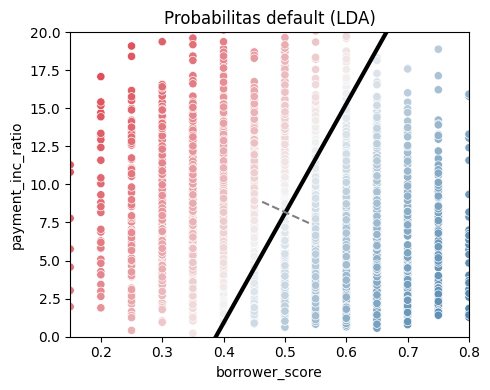

In [8]:
# Figure 5-1: batas keputusan LDA
center = np.mean(loan_lda.means_, axis=0)
slope = -loan_lda.scalings_[0, 0] / loan_lda.scalings_[1, 0]
intercept = center[1] - center[0] * slope

# Payment_inc_ratio untuk borrower_score 0 dan 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio', hue='default', data=lda_df,
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True), ax=ax, legend=False)
ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3, color='black')
ax.plot(*loan_lda.means_.transpose(), '--', color='gray')
ax.set_title('Probabilitas default (LDA)')
plt.tight_layout(); plt.show()

Garis hitam tebal adalah **batas keputusan** LDA (probabilitas = 0,5). Titik di sebelah kiri atas garis cenderung diprediksi `default` (merah), di sebelah kanan bawah cenderung `paid off` (biru). Semakin jauh dari garis, semakin yakin prediksinya.

### Perluasan
- LDA bisa dipakai untuk lebih dari dua kelas dan lebih dari dua prediktor.
- **Quadratic Discriminant Analysis (QDA)** — tidak mengasumsikan matriks kovarians yang sama untuk semua kelas, sehingga batas keputusannya bisa melengkung (kuadratik).
- LDA mengasumsikan prediktor berdistribusi normal, tapi dalam praktik cukup tahan (robust) terhadap pelanggaran asumsi ini, bahkan untuk prediktor biner.

## 3. Logistic Regression

**Logistic regression** mirip dengan regresi linear, tetapi outcome-nya biner. Ia populer karena:
- cepat dihitung,
- menghasilkan model yang mudah **diinterpretasikan**,
- mudah diterapkan untuk menilai data baru (*scoring*).

**Istilah kunci:**
- **Logit** — fungsi yang memetakan probabilitas (0–1) ke rentang $(-\infty, +\infty)$ (sinonim: log odds).
- **Odds** — rasio "sukses" (1) terhadap "tidak sukses" (0).
- **Log odds** — respons dalam model yang ditransformasi; dimodelkan secara linear terhadap prediktor.

### Dari probabilitas ke log odds
Kita tidak bisa memodelkan probabilitas $p$ langsung dengan persamaan linear, karena hasilnya bisa < 0 atau > 1. Maka kita lakukan transformasi:

**1. Logistic response function** (fungsi sigmoid):
$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_q x_q)}}$$
Fungsi ini selalu menghasilkan nilai antara 0 dan 1.

**2. Odds:**
$$\text{Odds}(Y=1) = \frac{p}{1-p}$$
Contoh: jika $p = 0{,}5$, odds = 1 ("50:50"). Jika $p = 0{,}8$, odds = 4.

**3. Log odds (logit):**
$$\log(\text{Odds}(Y=1)) = \beta_0 + \beta_1 x_1 + \dots + \beta_q x_q$$

Sekarang sisi kanan adalah persamaan linear biasa. Inilah yang diestimasi oleh logistic regression.

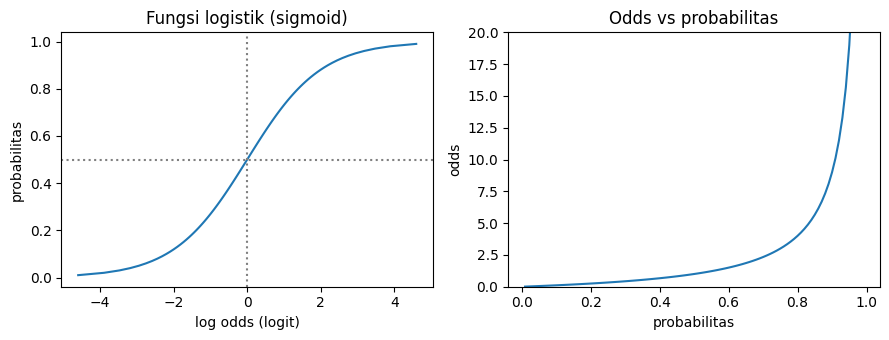

In [9]:
# Visualisasi fungsi logit dan sigmoid
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({'p': p, 'logit': np.log(p / (1 - p)), 'odds': p / (1 - p)})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(df['logit'], df['p'])
axes[0].set_xlabel('log odds (logit)'); axes[0].set_ylabel('probabilitas'); axes[0].set_title('Fungsi logistik (sigmoid)')
axes[0].axhline(0.5, color='gray', ls=':'); axes[0].axvline(0, color='gray', ls=':')
axes[1].plot(df['p'], df['odds'])
axes[1].set_xlabel('probabilitas'); axes[1].set_ylabel('odds'); axes[1].set_ylim(0, 20); axes[1].set_title('Odds vs probabilitas')
plt.tight_layout(); plt.show()

### Fitting Logistic Regression
Contoh: memprediksi default dari rasio cicilan/pendapatan, tujuan pinjaman, kepemilikan rumah, lama bekerja, dan skor peminjam.

Catatan teknis untuk scikit-learn:
- `LogisticRegression` secara default memakai **regularisasi**. Untuk meniru regresi logistik klasik (tanpa penalti), kita pakai nilai `C` yang sangat besar.
- Variabel kategorikal diubah menjadi dummy dengan `drop_first=True` (reference coding, seperti di Bab 4).

In [10]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
y = loan_data[outcome]

logit_reg = LogisticRegression(C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept:', float(logit_reg.intercept_[0]))
print('classes  :', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]}, index=X.columns).round(4)

intercept: -1.6380882883923482
classes  : ['default' 'paid off']


,coeff
payment_inc_ratio,-0.0797
borrower_score,4.6110
debt_consolidation,-0.2493
home_improvement,-0.4076
major_purchase,-0.2294
medical,-0.5101
other,-0.6205
small_business,-1.2157
OWN,-0.0485
RENT,-0.1574


**Hati-hati arah tanda:** scikit-learn mengurutkan label secara alfabetis, jadi `classes_ = ['default', 'paid off']`. Kelas "positif" (yang log odds-nya dimodelkan) adalah kelas **terakhir**, yaitu `paid off`. Artinya koefisien di atas adalah efek terhadap peluang **lunas**.

Untuk menafsirkannya terhadap **default**, cukup **balik tandanya**. Contoh: koefisien `borrower_score` = +4,61 untuk lunas berarti −4,61 untuk default (skor tinggi → peluang default turun). Di bagian berikutnya kita juga fit model yang sama dengan statsmodels memakai outcome 1 = default, sehingga tandanya langsung terhadap default.

### Predicted Values
Model menghasilkan **log odds**. Untuk mengubahnya menjadi probabilitas, pakai fungsi logistik. Di scikit-learn, `predict_proba` langsung memberikan probabilitas.

In [11]:
pred_logodds = pd.DataFrame(logit_reg.predict_log_proba(X), columns=logit_reg.classes_)
print('Log probabilitas:')
print(pred_logodds.describe().round(3))

pred = pd.DataFrame(logit_reg.predict_proba(X), columns=logit_reg.classes_)
print('\nProbabilitas:')
print(pred.describe().round(3))

Log probabilitas:
         default   paid off
count  45342.000  45342.000
mean      -0.758     -0.760
std        0.378      0.390
min       -2.769     -3.539
25%       -0.986     -0.977
50%       -0.697     -0.689
75%       -0.472     -0.467
max       -0.029     -0.065

Probabilitas:
         default   paid off
count  45342.000  45342.000
mean       0.500      0.500
std        0.167      0.167
min        0.063      0.029
25%        0.373      0.376
50%        0.498      0.502
75%        0.624      0.627
max        0.971      0.937


### Menafsirkan Koefisien dan Odds Ratio
Kelebihan utama logistic regression: koefisiennya bisa ditafsirkan sebagai **odds ratio**.
$$\text{Odds ratio} = \frac{\text{Odds}(Y=1 \mid X=1)}{\text{Odds}(Y=1 \mid X=0)}$$

Untuk koefisien $\beta_j$, nilai $e^{\beta_j}$ adalah **odds ratio**: perubahan multiplikatif pada odds ketika $X_j$ naik 1 unit.

Contoh (koefisien untuk **default**, yaitu tanda dibalik): koefisien `small_business` sekitar +1,22. Maka $e^{1{,}22} \approx 3{,}4$: pinjaman untuk usaha kecil punya **odds default sekitar 3,4 kali** dibanding pinjaman untuk melunasi kartu kredit (kategori referensi), dengan variabel lain tetap.

Untuk variabel numerik: koefisien `borrower_score` untuk default sekitar −4,61. Karena skornya 0–1, kita lihat perubahan 0,1 unit: $e^{-0{,}461} \approx 0{,}63$, jadi kenaikan skor 0,1 menurunkan odds default sekitar 37%.

**Kenapa memakai odds ratio, bukan rasio probabilitas?** Karena koefisien dalam log odds adalah aditif dan konstan, sedangkan efek terhadap probabilitas bergantung pada nilai variabel lain.

In [12]:
# Balik tanda supaya koefisien dan odds ratio dibaca terhadap DEFAULT
coef_default = -logit_reg.coef_[0]
odds = pd.DataFrame({'coeff_default': coef_default, 'odds_ratio_default': np.exp(coef_default)}, index=X.columns)
odds.round(3)

,coeff_default,odds_ratio_default
payment_inc_ratio,0.080,1.083
borrower_score,-4.611,0.010
debt_consolidation,0.249,1.283
home_improvement,0.408,1.503
major_purchase,0.229,1.258
medical,0.510,1.665
other,0.621,1.860
small_business,1.216,3.373
OWN,0.048,1.050
RENT,0.157,1.170


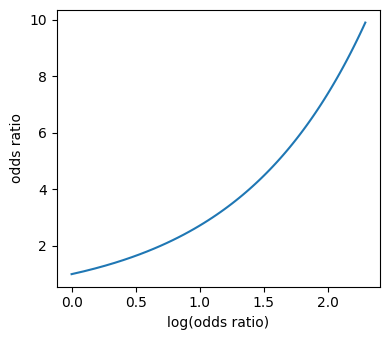

In [13]:
# Hubungan odds ratio dan log-odds ratio (Figure 5-3)
fig, ax = plt.subplots(figsize=(4, 3.5))
x = np.arange(1, 10, 0.1)
ax.plot(np.log(x), x)
ax.set_xlabel('log(odds ratio)'); ax.set_ylabel('odds ratio')
plt.tight_layout(); plt.show()

### Linear vs Logistic Regression: kemiripan dan perbedaan
| | Regresi linear | Regresi logistik |
|---|---|---|
| Outcome | Numerik kontinu | Biner (0/1) |
| Yang dimodelkan | $Y$ secara langsung | log odds dari $Y = 1$ |
| Metode fitting | Least squares | **Maximum likelihood estimation (MLE)** |
| Ukuran kecocokan | RMSE, R² | **Deviance**, AIC |

**Maximum Likelihood Estimation (MLE):** mencari parameter $\hat\beta$ yang membuat data yang kita amati **paling mungkin** terjadi. Tidak ada rumus tertutup seperti least squares; solusinya dicari secara iteratif (misalnya *Fisher's scoring*).

**Deviance** = $-2 \log(\text{likelihood})$. Semakin kecil semakin baik. Analog dengan residual sum of squares pada regresi linear.

### Menilai Model dengan statsmodels
`statsmodels` memberikan output lengkap: koefisien, standard error, z-value, dan p-value, mirip dengan regresi linear di Bab 4. Di sini kita perlu outcome numerik (1 = default).

In [14]:
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1), family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Fri, 09 Oct 2026   Deviance:                       57515.
Time:                        19:42:34   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

Interpretasi p-value sama seperti di regresi linear: dipakai sebagai **panduan relatif** pentingnya variabel, bukan uji signifikansi formal.

Semua konsep regresi linear dari Bab 4 juga berlaku di sini: **stepwise selection**, **interaksi**, **spline**, **confounding**, dan **korelasi antar prediktor**.

### Generalized Additive Model (GAM) untuk klasifikasi
Kita bisa menambahkan **spline** untuk prediktor numerik agar hubungan non-linear tertangkap. Di statsmodels, cukup pakai `bs()` dalam formula.

In [15]:
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
loan_gam_data = loan_data.assign(outcome=y_numbers)
model = smf.glm(formula=formula, data=loan_gam_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary().tables[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45321
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28731.
Date:                Fri, 09 Oct 2026   Deviance:                       57462.
Time:                        19:42:37   Pearson chi2:                 4.54e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1122
Covariance Type:            nonrobust                                         


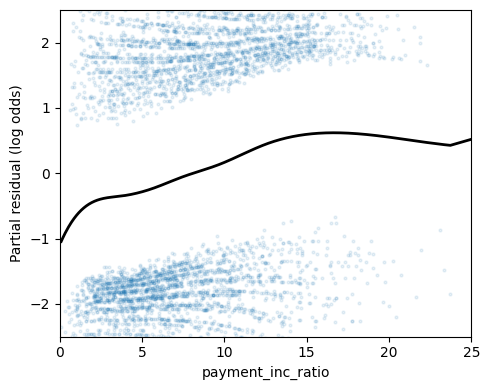

In [16]:
# Partial residual plot untuk payment_inc_ratio pada model GAM
from statsmodels.genmod.generalized_linear_model import GLMResults

def partial_residual_logistic(results, df, outcome, feature, ax):
    y_pred = results.predict(df)
    copy_df = df.copy()
    for c in copy_df.columns:
        if c == feature:
            continue
        if pd.api.types.is_numeric_dtype(copy_df[c]):
            copy_df[c] = float(copy_df[c].mean())
        else:
            copy_df[c] = copy_df[c].mode()[0]
    feature_logit = np.log(results.predict(copy_df) / (1 - results.predict(copy_df)))
    feature_logit = feature_logit - feature_logit.mean()
    logit_pred = np.log(y_pred / (1 - y_pred))
    resid = (df[outcome] - y_pred) / (y_pred * (1 - y_pred))   # working residual
    res = pd.DataFrame({'feature': df[feature], 'partial': feature_logit,
                        'presid': feature_logit + resid}).sort_values('feature')
    ax.scatter(res.feature, res.presid, s=4, alpha=0.1)
    ax.plot(res.feature, res.partial, color='black', lw=2)
    return ax

sample = loan_gam_data.sample(5000, random_state=1)
fig, ax = plt.subplots(figsize=(5, 4))
partial_residual_logistic(results, sample, 'outcome', 'payment_inc_ratio', ax)
ax.set_xlim(0, 25); ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('payment_inc_ratio'); ax.set_ylabel('Partial residual (log odds)')
plt.tight_layout(); plt.show()

Garis hitam adalah efek estimasi `payment_inc_ratio` terhadap log odds default: naik cukup cepat pada rasio rendah lalu cenderung melandai. Titik-titik di plot regresi logistik membentuk **dua "awan"** (atas untuk default, bawah untuk lunas), karena outcome-nya biner. Bentuk plot ini lebih sulit dibaca dibanding regresi linear, tapi tetap berguna untuk melihat non-linearitas dan outlier.

## 4. Generalized Linear Models (GLM)

Logistic regression adalah contoh khusus dari **Generalized Linear Model (GLM)**. GLM punya dua komponen utama:
- **Distribusi probabilitas** (*family*) — untuk logistic regression: **binomial**.
- **Link function** — fungsi yang menghubungkan respons dengan prediktor linear. Untuk logistic regression: **logit**.

Contoh GLM lain:
| Jenis outcome | Family | Link |
|---|---|---|
| Biner (ya/tidak) | Binomial | logit |
| Hitungan (count) | Poisson | log |
| Hitungan dengan overdispersi | Negative binomial | log |
| Waktu sampai kejadian | Gamma | log/inverse |
| Numerik kontinu | Gaussian | identity (= regresi linear biasa) |

Contoh: **Poisson regression** cocok untuk memodelkan jumlah kunjungan ke website per hari; **Gamma** cocok untuk waktu sampai kegagalan.

## 5. Evaluasi Model Klasifikasi

Model klasifikasi dinilai dari **seberapa akurat prediksinya**. Metrik paling sederhana adalah **akurasi**:
$$\text{accuracy} = \frac{\sum \text{TruePositive} + \sum \text{TrueNegative}}{\text{Sample Size}}$$

Tapi akurasi saja bisa menyesatkan, terutama untuk **data tidak seimbang** (misalnya fraud yang hanya 0,1% dari transaksi: model yang selalu menebak "bukan fraud" punya akurasi 99,9% tapi tidak berguna).

**Istilah kunci:**
- **Accuracy** — persentase klasifikasi yang benar.
- **Confusion matrix** — tabel hitungan prediksi vs aktual per kelas.
- **Sensitivity / Recall** — persentase kelas 1 yang berhasil diprediksi benar.
- **Specificity** — persentase kelas 0 yang berhasil diprediksi benar.
- **Precision** — persentase prediksi 1 yang memang benar 1.
- **ROC curve** — plot sensitivity vs specificity untuk berbagai cutoff.
- **Lift** — seberapa efektif model menemukan kelas 1 pada berbagai cutoff (dibanding pemilihan acak).

### Confusion Matrix
|  | Prediksi 1 | Prediksi 0 |
|---|---|---|
| **Aktual 1** | True Positive (TP) | False Negative (FN) |
| **Aktual 0** | False Positive (FP) | True Negative (TN) |

In [17]:
pred = logit_reg.predict(X)
pred_y = pred == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[int(np.sum(true_pos)), int(np.sum(false_neg))],
                         [int(np.sum(false_pos)), int(np.sum(true_neg))]],
                        index=['Y = default', 'Y = paid off'],
                        columns=['Yhat = default', 'Yhat = paid off'])
conf_mat

,Yhat = default,Yhat = paid off
Y = default,14336,8335
Y = paid off,8148,14523


In [18]:
# Versi scikit-learn (urutan label ditentukan manual)
print(confusion_matrix(y, logit_reg.predict(X), labels=['default', 'paid off']))

[[14336  8335]
 [ 8148 14523]]


### Precision, Recall, dan Specificity
$$\text{precision} = \frac{TP}{TP + FP} \qquad \text{recall} = \frac{TP}{TP + FN} \qquad \text{specificity} = \frac{TN}{TN + FP}$$

- **Precision** — dari semua yang diprediksi default, berapa persen yang benar default?
- **Recall (sensitivity)** — dari semua yang benar-benar default, berapa persen yang tertangkap?
- **Specificity** — dari semua yang benar-benar lunas, berapa persen yang diprediksi benar?

Ada **trade-off**: menurunkan cutoff akan menaikkan recall (lebih banyak default tertangkap) tapi menurunkan specificity dan biasanya precision (lebih banyak alarm palsu).

In [19]:
cm = conf_mat.values
TP, FN, FP, TN = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print(f'Accuracy   : {(TP + TN) / cm.sum():.3f}')
print(f'Precision  : {TP / (TP + FP):.3f}')
print(f'Recall     : {TP / (TP + FN):.3f}')
print(f'Specificity: {TN / (TN + FP):.3f}')

print('\nscikit-learn (baris pertama = default, kedua = paid off):')
p_, r_, f_, s_ = precision_recall_fscore_support(y, logit_reg.predict(X), labels=['default', 'paid off'])
print('precision:', p_.round(3), '| recall:', r_.round(3), '| f1:', f_.round(3))

Accuracy   : 0.636
Precision  : 0.638
Recall     : 0.632
Specificity: 0.641

scikit-learn (baris pertama = default, kedua = paid off):
precision: [0.638 0.635] | recall: [0.632 0.641] | f1: [0.635 0.638]


Perhatikan: **recall kelas `paid off`** sama dengan **specificity** jika kelas 1 adalah `default`.

### ROC Curve
**Receiver Operating Characteristics (ROC) curve** memperlihatkan trade-off antara recall dan specificity untuk **semua kemungkinan cutoff**. Istilah ini berasal dari Perang Dunia II, ketika operator radar harus membedakan sinyal pesawat musuh dari noise.

Cara membuat:
1. Urutkan record berdasarkan probabilitas kelas 1, dari tertinggi ke terendah.
2. Untuk setiap cutoff, hitung sensitivity dan specificity.
3. Plot sensitivity (sumbu y) terhadap 1 − specificity / false positive rate (sumbu x).

Garis diagonal = model yang **tidak lebih baik dari tebakan acak**. Semakin dekat kurva ke **pojok kiri atas**, semakin baik modelnya.

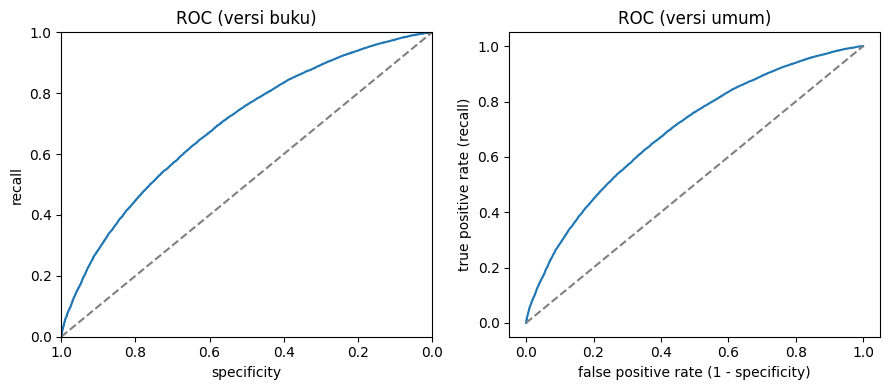

In [20]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, list(logit_reg.classes_).index('default')],
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ax = roc_df.plot(x='specificity', y='recall', ax=axes[0], legend=False)
ax.set_ylim(0, 1); ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1), color='gray', ls='--')
ax.set_xlabel('specificity'); ax.set_ylabel('recall'); ax.set_title('ROC (versi buku)')

axes[1].plot(fpr, tpr)
axes[1].plot((0, 1), (0, 1), color='gray', ls='--')
axes[1].set_xlabel('false positive rate (1 - specificity)'); axes[1].set_ylabel('true positive rate (recall)')
axes[1].set_title('ROC (versi umum)')
plt.tight_layout(); plt.show()

### AUC (Area Under the Curve)
ROC curve adalah alat visual. Untuk merangkumnya menjadi satu angka, hitung **luas di bawah kurva (AUC)**:
- **AUC = 1** → model sempurna.
- **AUC = 0,5** → sama dengan tebakan acak.
- Semakin tinggi AUC, semakin baik model membedakan kelas.

AUC (integrasi manual): 0.6917
AUC (scikit-learn)    : 0.6917


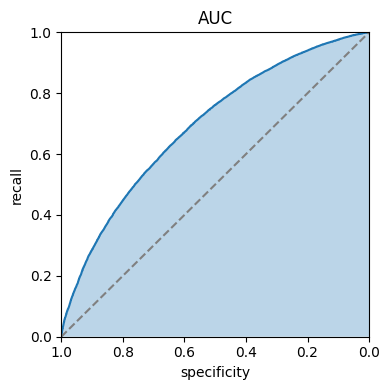

In [21]:
prob_default = logit_reg.predict_proba(X)[:, list(logit_reg.classes_).index('default')]
print(f'AUC (integrasi manual): {np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)):.4f}')
print(f'AUC (scikit-learn)    : {roc_auc_score([1 if yi == "default" else 0 for yi in y], prob_default):.4f}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(roc_df['specificity'], roc_df['recall'])
ax.fill_between(roc_df['specificity'], 0, roc_df['recall'], alpha=0.3)
ax.set_ylim(0, 1); ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1), color='gray', ls='--')
ax.set_xlabel('specificity'); ax.set_ylabel('recall'); ax.set_title('AUC')
plt.tight_layout(); plt.show()

AUC model ini sekitar **0,69**: lebih baik dari acak, tapi masih jauh dari sempurna. Memprediksi default pinjaman memang sulit.

**Kebingungan istilah false positive rate:** di beberapa bidang, "false positive rate" berarti proporsi negatif sebenarnya yang diprediksi positif (= 1 − specificity). Di bidang lain (misalnya medis), bisa berarti proporsi prediksi positif yang ternyata negatif (= 1 − precision). Pastikan definisinya jelas.

### Lift
AUC menilai model di **semua** cutoff. Tapi dalam praktik, kita sering hanya peduli pada **bagian teratas** prediksi. Contoh: tim penagihan hanya bisa menghubungi 10% peminjam dengan risiko tertinggi. Pertanyaannya: berapa banyak default yang tertangkap di 10% teratas itu, dibanding memilih acak?

**Lift** = proporsi kelas 1 di kelompok teratas ÷ proporsi kelas 1 secara keseluruhan.
- Lift = 2 pada desil teratas berarti model menemukan kelas 1 **dua kali lebih efektif** daripada pemilihan acak.

**Gains chart (cumulative gains)** memplot persentase kelas 1 yang tertangkap terhadap persentase data yang diambil.

In [22]:
lift_df = pd.DataFrame({'prob': prob_default, 'actual': [1 if yi == 'default' else 0 for yi in y]})
lift_df = lift_df.sort_values('prob', ascending=False).reset_index(drop=True)
lift_df['decile'] = pd.qcut(lift_df.index, 10, labels=range(1, 11))

base_rate = lift_df['actual'].mean()
decile_stats = lift_df.groupby('decile', observed=True)['actual'].agg(['mean', 'sum'])
decile_stats['lift'] = decile_stats['mean'] / base_rate
decile_stats['cum_gain'] = decile_stats['sum'].cumsum() / lift_df['actual'].sum()
print(f'Base rate default: {base_rate:.3f}')
decile_stats.round(3)

Base rate default: 0.500


,mean,sum,lift,cum_gain
decile,,,,
1,0.779,3532,1.558,0.156
2,0.697,3158,1.393,0.295
3,0.624,2827,1.247,0.420
4,0.565,2561,1.130,0.533
5,0.517,2346,1.035,0.636
6,0.485,2201,0.971,0.733
7,0.434,1969,0.869,0.820
8,0.377,1709,0.754,0.896
9,0.309,1403,0.619,0.957


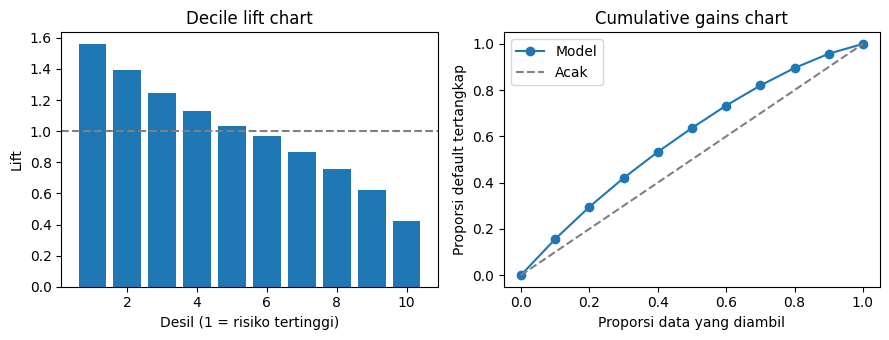

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(decile_stats.index.astype(int), decile_stats['lift'])
axes[0].axhline(1, color='gray', ls='--')
axes[0].set_xlabel('Desil (1 = risiko tertinggi)'); axes[0].set_ylabel('Lift'); axes[0].set_title('Decile lift chart')

x_pct = np.arange(0, 11) / 10
axes[1].plot(x_pct, [0] + list(decile_stats['cum_gain']), marker='o', label='Model')
axes[1].plot([0, 1], [0, 1], color='gray', ls='--', label='Acak')
axes[1].set_xlabel('Proporsi data yang diambil'); axes[1].set_ylabel('Proporsi default tertangkap')
axes[1].set_title('Cumulative gains chart'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Strategi untuk Data Tidak Seimbang

**Imbalanced data** adalah masalah besar dalam klasifikasi: kelas yang diminati (fraud, churn, default, klik) sering hanya sebagian kecil data. Model yang dilatih pada data seperti ini cenderung mengabaikan kelas langka itu.

**Istilah kunci:**
- **Undersample** — memakai lebih sedikit record dari kelas mayoritas.
- **Oversample** — memakai lebih banyak record dari kelas minoritas (bootstrap jika perlu).
- **Up weight / down weight** — memberi bobot lebih besar (atau lebih kecil) pada kelas minoritas (atau mayoritas).
- **Data generation** — seperti bootstrap, tapi tiap record baru sedikit berbeda dari sumbernya.
- **z-score** — nilai setelah standardisasi.
- **K** — jumlah tetangga dalam perhitungan nearest-neighbor.

Contoh: dataset pinjaman lengkap (`full_train_set`), di mana hanya sekitar **19%** pinjaman yang default.

In [24]:
full_train_set = pd.read_csv(DATA + 'full_train_set.csv.gz')
print(full_train_set.shape)
print('Proporsi default:', round(float(np.mean(full_train_set.outcome == 'default')), 4))

(119987, 19)
Proporsi default: 0.1889


In [25]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X_full = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
y_full = full_train_set[outcome]

full_model = LogisticRegression(C=1e42, solver='liblinear')
full_model.fit(X_full, y_full)
print('Persentase pinjaman yang DIPREDIKSI default:',
      round(100 * float(np.mean(full_model.predict(X_full) == 'default')), 2), '%')

Persentase pinjaman yang DIPREDIKSI default: 0.98 %


Walaupun 19% pinjaman sebenarnya default, model hanya memprediksi sekitar **1%** sebagai default. Model "malas": ia hampir selalu menebak kelas mayoritas karena itu sudah memberi akurasi tinggi.

### Undersampling
Jika data cukup banyak, salah satu solusi adalah **mengurangi kelas mayoritas** sampai kedua kelas seimbang. Inilah yang dipakai dataset `loan_data` di bab ini: jumlah default dan lunas dibuat sama (~22.671 masing-masing).

Model pada data seimbang memprediksi default sekitar 50%. Kelemahannya: kita membuang data, dan probabilitas yang dihasilkan **bias** ke arah kelas minoritas (perlu dikoreksi jika butuh probabilitas yang akurat).

In [26]:
print('Proporsi default di loan_data (undersampled):', round(float(np.mean(loan_data.outcome == 'default')), 3))
print('Persentase prediksi default (model di loan_data):',
      round(100 * float(np.mean(logit_reg.predict(X) == 'default')), 1), '%')

Proporsi default di loan_data (undersampled): 0.5
Persentase prediksi default (model di loan_data): 49.6 %


### Oversampling dan Up/Down Weighting
Alih-alih membuang data mayoritas, kita bisa **memberi bobot lebih besar** pada kelas minoritas. Bobot default dibuat sebesar $1/p$, dengan $p$ = proporsi default, sehingga total bobot kedua kelas kira-kira seimbang.

Ini setara dengan oversampling, tetapi tanpa menduplikasi data.

In [27]:
default_wt = 1 / float(np.mean(full_train_set.outcome == 'default'))
wt = [default_wt if outcome == 'default' else 1 for outcome in full_train_set.outcome]

full_model_wt = LogisticRegression(C=1e42, solver='liblinear')
full_model_wt.fit(X_full, y_full, sample_weight=wt)
print('Bobot kelas default:', round(default_wt, 3))
print('Persentase pinjaman yang diprediksi default (weighted):',
      round(100 * float(np.mean(full_model_wt.predict(X_full) == 'default')), 1), '%')

Bobot kelas default: 5.293
Persentase pinjaman yang diprediksi default (weighted): 61.8 %


Dengan pembobotan, sekitar **60%** pinjaman diprediksi default. Ini jauh lebih sensitif terhadap default (meski sekarang lebih banyak alarm palsu).

Banyak model scikit-learn juga mendukung `class_weight='balanced'`, yang menghitung bobot ini secara otomatis.

In [28]:
model_balanced = LogisticRegression(C=1e42, solver='liblinear', class_weight='balanced')
model_balanced.fit(X_full, y_full)
print('Persentase prediksi default (class_weight="balanced"):',
      round(100 * float(np.mean(model_balanced.predict(X_full) == 'default')), 1), '%')

Persentase prediksi default (class_weight="balanced"): 42.7 %


### Data Generation: SMOTE
Variasi dari oversampling: alih-alih menduplikasi record minoritas, kita **membuat record baru yang sedikit berbeda** dari record yang ada. Algoritma paling terkenal: **SMOTE (Synthetic Minority Oversampling Technique)**.

Cara kerja SMOTE:
1. Untuk sebuah record minoritas, cari **K nearest neighbors**-nya (di kelas minoritas juga).
2. Pilih salah satu tetangga secara acak.
3. Buat record sintetis di antara record asli dan tetangganya: setiap prediktor diinterpolasi secara acak di antara dua nilai tersebut.

Prediktor sebaiknya distandardisasi (z-score) dulu agar jarak antar record bermakna. Implementasi Python tersedia di paket `imbalanced-learn`.

In [29]:
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    X_resampled, y_resampled = SMOTE().fit_resample(X_full, y_full)
    print('Proporsi default setelah SMOTE:', round(float(np.mean(y_resampled == 'default')), 3))

    full_model_smote = LogisticRegression(C=1e42, solver='liblinear')
    full_model_smote.fit(X_resampled, y_resampled)
    print('Persentase prediksi default (SMOTE)  :',
          round(100 * float(np.mean(full_model_smote.predict(X_full) == 'default')), 1), '%')

    X_resampled, y_resampled = ADASYN().fit_resample(X_full, y_full)
    full_model_adasyn = LogisticRegression(C=1e42, solver='liblinear')
    full_model_adasyn.fit(X_resampled, y_resampled)
    print('Persentase prediksi default (ADASYN) :',
          round(100 * float(np.mean(full_model_adasyn.predict(X_full) == 'default')), 1), '%')
except ImportError:
    print('Paket imbalanced-learn belum terpasang. Jalankan: pip install imbalanced-learn')

Proporsi default setelah SMOTE: 0.5
Persentase prediksi default (SMOTE)  : 29.4 %
Persentase prediksi default (ADASYN) : 27.4 %


**ADASYN** adalah varian SMOTE yang membuat lebih banyak data sintetis di area yang sulit diklasifikasikan.

### Cost-Based Classification
Dalam praktik, ukuran terbaik bukan akurasi atau AUC, tapi **biaya/keuntungan nyata**. Contoh dari buku: untuk pinjaman,
- pinjaman yang lunas menghasilkan keuntungan (bunga),
- pinjaman default menyebabkan kerugian (sebagian pokok hilang).

Maka keputusan terbaik bukan sekadar "default atau tidak", tapi **expected return**:
$$\text{Expected return} = P(Y=0) \times \text{keuntungan} - P(Y=1) \times \text{kerugian}$$

Pinjaman disetujui jika expected return-nya positif. Cutoff probabilitas bisa ditentukan berdasarkan analisis biaya ini.

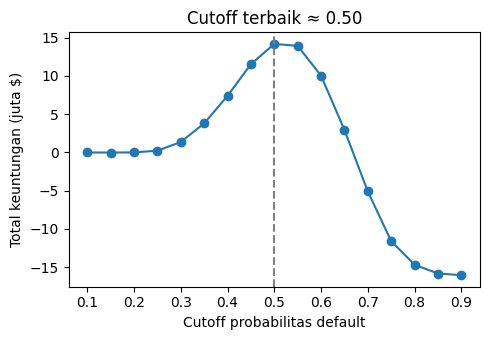

In [30]:
# Ilustrasi: cutoff optimal berdasarkan biaya (asumsi sederhana)
profit_paid = 1000      # keuntungan rata-rata dari pinjaman lunas
loss_default = 5000     # kerugian rata-rata dari pinjaman default

p_def = full_model_wt.predict_proba(X_full)[:, list(full_model_wt.classes_).index('default')]
actual_def = (y_full == 'default').values

cutoffs = np.arange(0.1, 0.95, 0.05)
profits = []
for c in cutoffs:
    approve = p_def < c                       # setujui jika probabilitas default di bawah cutoff
    profit = profit_paid * np.sum(approve & ~actual_def) - loss_default * np.sum(approve & actual_def)
    profits.append(profit)

best = cutoffs[int(np.argmax(profits))]
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(cutoffs, np.array(profits) / 1e6, marker='o')
ax.axvline(best, color='gray', ls='--')
ax.set_xlabel('Cutoff probabilitas default'); ax.set_ylabel('Total keuntungan (juta $)')
ax.set_title(f'Cutoff terbaik ≈ {best:.2f}')
plt.tight_layout(); plt.show()

Angka keuntungan dan kerugian di atas hanya ilustrasi, tetapi idenya sama: **cutoff optimal ditentukan oleh konsekuensi bisnis**, bukan oleh angka 0,5.

## 7. Menjelajahi Prediksi

Satu metrik seperti AUC tidak menceritakan semuanya. Buku menyarankan untuk **memvisualisasikan aturan prediksi** dari beberapa model untuk memahami perilakunya.

Contoh: dengan dua prediktor (`borrower_score` dan `payment_inc_ratio`) pada data `loan3000`, kita bandingkan **batas keputusan** (probabilitas = 0,5) dari:
- **Logistic regression** — batas lurus (linear).
- **LDA** — juga batas lurus, mirip logistic.
- **GAM logistik (spline)** — batas melengkung.
- **Decision tree** — batas berbentuk tangga (dibahas di Bab 6).

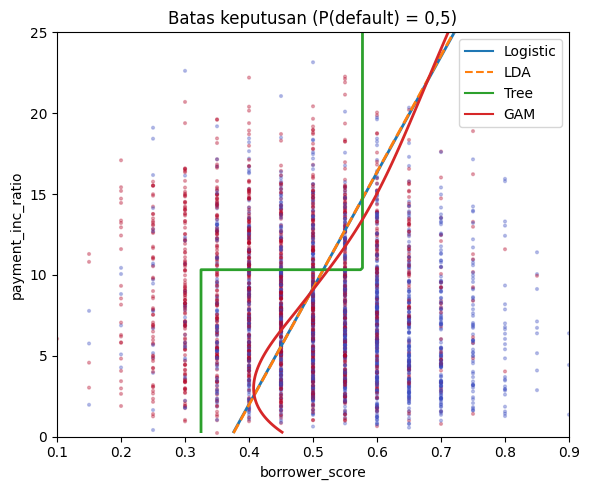

In [31]:
loan3000_num = loan3000.assign(outcome_num=(loan3000.outcome == 'default').astype(int))
Xg = loan3000[['borrower_score', 'payment_inc_ratio']]
yg = loan3000['outcome']

# Grid untuk menggambar batas keputusan
# Grid dibatasi ke rentang data supaya spline (GAM) tidak perlu ekstrapolasi
bs_grid, pir_grid = np.meshgrid(
    np.linspace(loan3000.borrower_score.min(), loan3000.borrower_score.max(), 200),
    np.linspace(loan3000.payment_inc_ratio.min(), min(loan3000.payment_inc_ratio.max(), 25), 200))
grid = pd.DataFrame({'borrower_score': bs_grid.ravel(), 'payment_inc_ratio': pir_grid.ravel()})

def prob_default_of(model, data):
    return model.predict_proba(data)[:, list(model.classes_).index('default')]

models = {
    'Logistic': LogisticRegression(C=1e42, solver='liblinear').fit(Xg, yg),
    'LDA': LinearDiscriminantAnalysis().fit(Xg, yg),
    'Tree': DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.003, random_state=1).fit(Xg, yg),
}
probs = {name: prob_default_of(m, grid) for name, m in models.items()}

gam_fit = smf.glm('outcome_num ~ bs(payment_inc_ratio, df=4) + bs(borrower_score, df=4)',
                  data=loan3000_num, family=sm.families.Binomial()).fit()
probs['GAM'] = gam_fit.predict(grid).values

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'Logistic': 'C0', 'LDA': 'C1', 'Tree': 'C2', 'GAM': 'C3'}
for name, pr in probs.items():
    ls = '--' if name == 'LDA' else '-'
    ax.contour(bs_grid, pir_grid, pr.reshape(bs_grid.shape), levels=[0.5], colors=colors[name],
               linewidths=2, linestyles=ls)
    ax.plot([], [], color=colors[name], ls=ls, label=name)
ax.scatter(loan3000.borrower_score, loan3000.payment_inc_ratio,
           c=(loan3000.outcome == 'default'), cmap='coolwarm', s=4, alpha=0.3)
ax.set_xlim(0.1, 0.9); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
ax.set_title('Batas keputusan (P(default) = 0,5)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

Beberapa pengamatan:
- **Logistic** dan **LDA** menghasilkan garis lurus yang hampir sama.
- **GAM** menghasilkan kurva: efek `payment_inc_ratio` tidak konstan.
- **Decision tree** menghasilkan batas berbentuk tangga dan bisa "aneh" di area dengan sedikit data. Ini tanda bahwa tree tunggal mudah **overfit**.
- Di wilayah dengan `payment_inc_ratio` tinggi, data sangat jarang, sehingga prediksi semua model di sana kurang bisa dipercaya.

Visualisasi seperti ini membantu kita memahami **kenapa** model memberikan prediksi tertentu dan di mana model mungkin tidak bisa diandalkan.